<a href="https://colab.research.google.com/github/olcaykursun/ML/blob/main/Spring2026/autoencoder_vs_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# Linear Autoencoder vs PCA on Iris
# =========================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load Iris ----
iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target

# ---- PCA (1 component) ----
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

# ---- Torch Tensor ----
X_tensor = torch.tensor(X).to(device)

# ---- Linear Autoencoder: 4 -> 1 -> 4 ----
class LinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(4, 1)
        self.decoder = nn.Linear(1, 4)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = LinearAE().to(device)

opt = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

# ---- Train ----
for epoch in range(2000):
    opt.zero_grad()
    recon = model(X_tensor)
    loss = loss_fn(recon, X_tensor)
    loss.backward()
    opt.step()

# ---- Extract Latent ----
with torch.no_grad():
    X_ae = model.encoder(X_tensor).cpu().numpy()

# ---- Compare ----
# Compute correlation between PCA and AE
corr = np.corrcoef(X_pca.T, X_ae.T)[0, 1]

print("Correlation between PCA and Linear AE components:")
print(np.round(corr, 3))


Correlation between PCA and Linear AE components:
-0.998


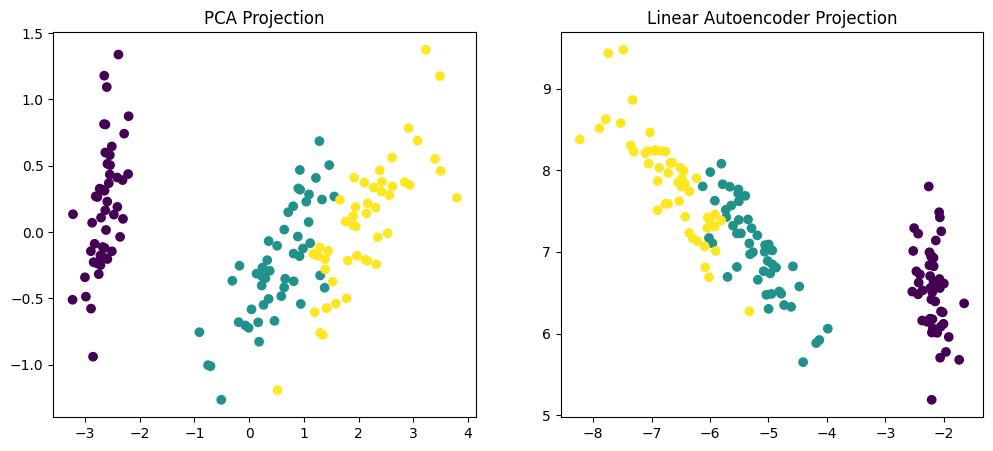

In [ ]:
# =========================================
# Linear Autoencoder vs PCA on Iris
# =========================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load Iris ----
iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target

# ---- PCA (2 components) ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ---- Torch Tensor ----
X_tensor = torch.tensor(X).to(device)

# ---- Linear Autoencoder: 4 -> 2 -> 4 ----
class LinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(4, 2)
        self.decoder = nn.Linear(2, 4)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = LinearAE().to(device)

opt = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

# ---- Train ----
for epoch in range(2000):
    opt.zero_grad()
    recon = model(X_tensor)
    loss = loss_fn(recon, X_tensor)
    loss.backward()
    opt.step()

# ---- Extract Latent ----
with torch.no_grad():
    X_ae = model.encoder(X_tensor).cpu().numpy()

# ---- Plot ----
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA Projection")

plt.subplot(1,2,2)
plt.scatter(X_ae[:,0], X_ae[:,1], c=y)
plt.title("Linear Autoencoder Projection")

plt.show()


In [ ]:
C = np.corrcoef(X_pca.T, X_ae.T)
print(np.round(C, 3))

[[ 1.     0.    -0.999  0.782]
 [ 0.     1.     0.037  0.615]
 [-0.999  0.037  1.    -0.758]
 [ 0.782  0.615 -0.758  1.   ]]


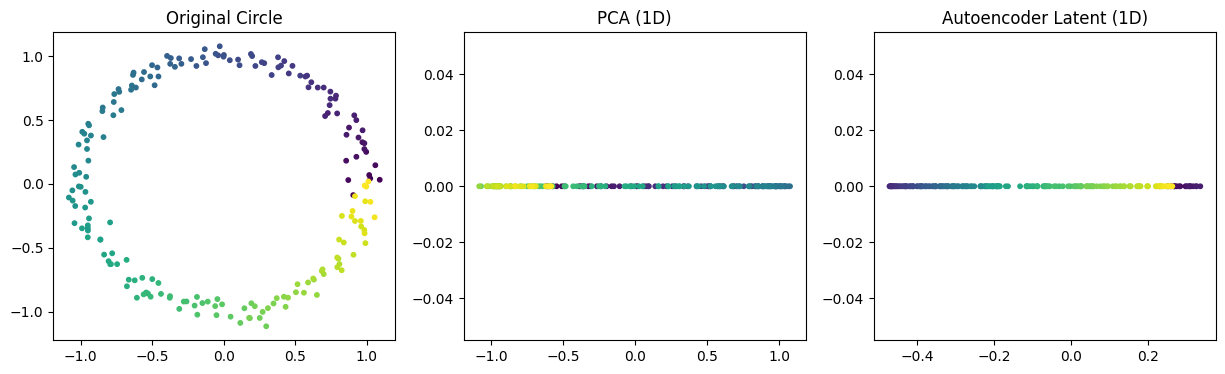

In [ ]:
# =========================================
# Circle: PCA vs Autoencoder (Topology Demo)
# =========================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Generate Circle ----
n = 200
theta = np.linspace(0, 2*np.pi, n)
x = np.cos(theta)
y = np.sin(theta)

X = np.stack([x, y], axis=1)
X += 0.05 * np.random.randn(*X.shape)  # small noise
X = X.astype(np.float32)

# ---- PCA to 1D ----
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

# ---- Torch Tensor ----
X_tensor = torch.tensor(X).to(device)

# ---- Autoencoder 2 -> 16 -> 1 -> 16 -> 2 ----
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2,16),
            nn.ReLU(),
            nn.Linear(16,1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1,16),
            nn.ReLU(),
            nn.Linear(16,2)
        )
    def forward(self,x):
        z = self.encoder(x)
        return self.decoder(z)

ae = AE().to(device)
opt = optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ---- Train ----
for epoch in range(5000):
    opt.zero_grad()
    recon = ae(X_tensor)
    loss = loss_fn(recon, X_tensor)
    loss.backward()
    opt.step()

# ---- Extract Latent ----
with torch.no_grad():
    z = ae.encoder(X_tensor).cpu().numpy().flatten()

# ---- Plot ----
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X[:,0], X[:,1], c=theta, s=10)
plt.title("Original Circle")

plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], np.zeros_like(X_pca[:,0]), c=theta, s=10)
plt.title("PCA (1D)")

plt.subplot(1,3,3)
plt.scatter(z, np.zeros_like(z), c=theta, s=10)
plt.title("Autoencoder Latent (1D)")

plt.show()
